<a href="https://colab.research.google.com/github/ArielQb14/Citra-Digital/blob/main/tugas_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prototype Verifikasi Ijazah — Google Colab

Notebook ini menjalankan pipeline:
1. Upload citra ijazah.
2. Grayscale dan image enhancement.
3. OCR nomor ijazah menggunakan Tesseract.
4. Deteksi indikasi tanda tangan melalui thresholding + morphology.
5. Perbandingan CER antar-metode enhancement.

**Catatan:** sesuaikan koordinat ROI untuk tata letak ijazah yang digunakan. Deteksi tanda tangan hanya mencari pola tinta di area tersebut, bukan membuktikan keaslian ijazah/tanda tangan.


## 1. Instalasi library dan Tesseract

In [3]:
!apt-get -qq update
!apt-get -qq install -y tesseract-ocr
!pip -q install opencv-python-headless pytesseract


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


## 2. Upload gambar ijazah

Saving 01_HighQuality_Enhanced.jpg to 01_HighQuality_Enhanced.jpg
File: 01_HighQuality_Enhanced.jpg | Ukuran: 2481 x 3506


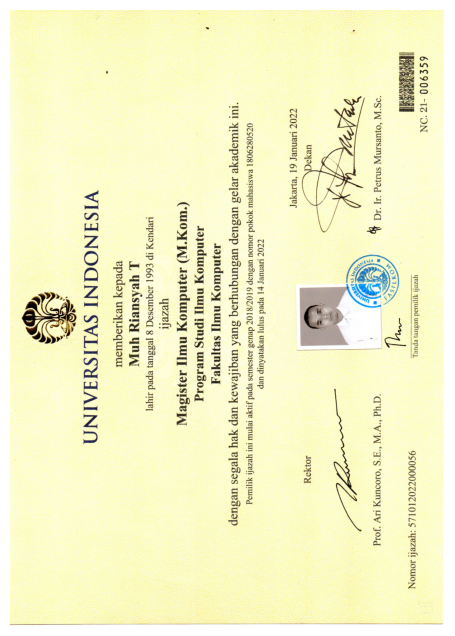

In [4]:
from google.colab import files
uploaded = files.upload()  # Pilih file JPG atau PNG, misalnya ijazah_001.jpg

import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import re, os
from PIL import Image

filename = next(iter(uploaded))
img = cv2.imread(filename)
if img is None:
    raise ValueError("Gambar tidak terbaca. Unggah file JPG atau PNG.")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
print(f"File: {filename} | Ukuran: {w} x {h}")
plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.axis("off");


## 3. Tentukan ROI (area) nomor dan tanda tangan

Nilai berikut adalah contoh awal berbentuk persentase gambar. **Ubah koordinatnya sesuai gambar yang diunggah.** Koordinat x1/y1 adalah sudut kiri-atas, x2/y2 sudut kanan-bawah; rentang 0–1.

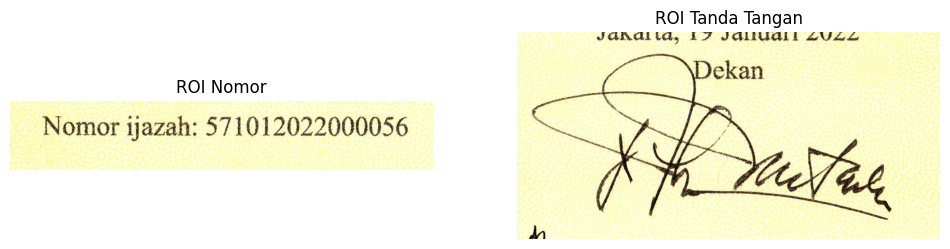

In [25]:
# Putar gambar agar orientasi ijazah tegak
img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

# Area nomor ijazah — setelah gambar diputar
number_roi_norm = (0.04, 0.90, 0.30, 0.96)

# Area tanda tangan Dekan
signature_roi_norm = (0.63, 0.65, 0.89, 0.83)

def crop_roi(image, coords):
    x1, y1, x2, y2 = coords
    hh, ww = image.shape[:2]
    xa, ya = int(x1*ww), int(y1*hh)
    xb, yb = int(x2*ww), int(y2*hh)
    xa, ya = max(0, xa), max(0, ya)
    xb, yb = min(ww, max(xa+1, xb)), min(hh, max(ya+1, yb))
    return image[ya:yb, xa:xb].copy()

number_roi = crop_roi(img, number_roi_norm)
signature_roi = crop_roi(img, signature_roi_norm)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cv2.cvtColor(number_roi, cv2.COLOR_BGR2RGB)); ax[0].set_title("ROI Nomor"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(signature_roi, cv2.COLOR_BGR2RGB)); ax[1].set_title("ROI Tanda Tangan"); ax[1].axis("off")
plt.show()


## 4. Image enhancement dan OCR

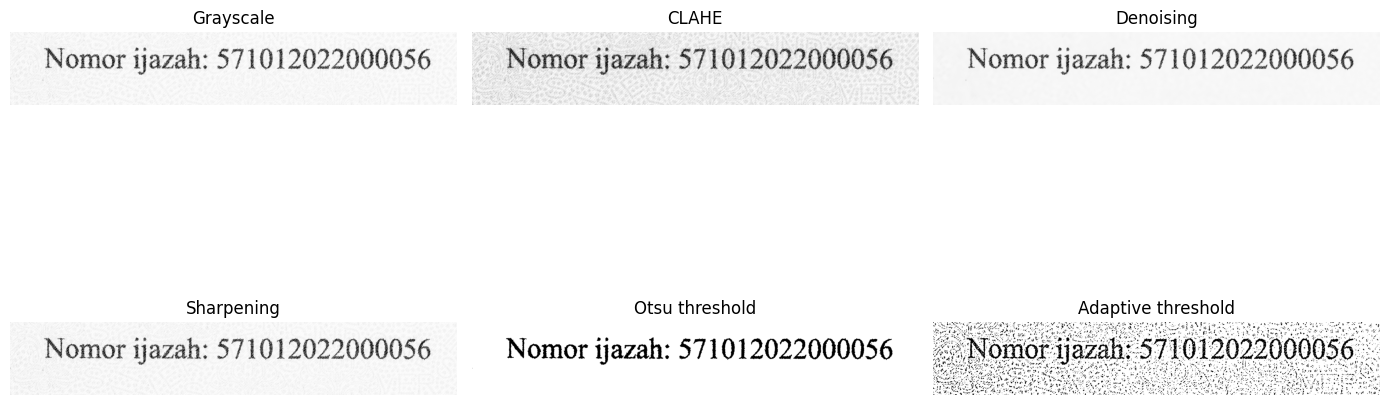

Hasil OCR per metode:
Grayscale           : NOMORYAZAH571012022000056
CLAHE               : NOMORYAZAH571012022000056
Denoising           : NOMORYAZAH571012022000056
Sharpening          : NOMORYAZAH571012022000056
Otsu threshold      : NOMORYAZAH571012022000056
Adaptive threshold  : VEEIEOTWAYAREABEEAEMGAEEATPATOEAPIEESSTETTNEESEOURBATTADLENAEAOATONAETAGSEPMEEERSEEOISSBGNEPUEECEADMPAOOONEEEESANALNHTEEELANAEPYUEPETYSAEENETAIETSLEESSRIEELRGEGTTITYMOSETE7AEITACOITYAKSAEEETARAETEECEDSOGMOENSIXEY-4-7FKWTYDIERRECNEROUEN-SEADESEEOS-OOEEEMEEMYANODAEACEEESAANBD-RAEEAOSIF7ATSEONROYHGOEEEYBECOYECGELEAENSOMIEETNIESEADAENERAITWEFREEETECTEEMETATTNMSOONREEBELTONHEYPASOSAPSSFASENEAESAEAKPEYAFEETBAEBESAYEREOSITEMIEFARELMOSTEEETPIICENCAECRRTA0CCASESEOFHIROEIRSRROOOEDEYEOCCLSSBOURBRCECEUEIOCESSNEEFODOBOMHSONEEERCTTAEEEEEBBANMAEHOERPIESPTSEALEPAGEPEGHEPEHDSOHEABEESEFCREYEESOENBEGEGEEBEENDNNEPYAESEAYTTESEGELOAOETYELEVENARTLESTITESGETEEEETHSEYAOFEGEEEEEPEPTEEAEWBO4YYHA-


In [26]:
def preprocess_variants(roi):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY) if roi.ndim == 3 else roi.copy()
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    denoise = cv2.fastNlMeansDenoising(gray, None, h=10, templateWindowSize=7, searchWindowSize=21)
    gaussian = cv2.GaussianBlur(gray, (3, 3), 0)
    sharpen = cv2.addWeighted(gray, 1.7, gaussian, -0.7, 0)
    _, otsu = cv2.threshold(clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    adaptive = cv2.adaptiveThreshold(clahe, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 31, 11)
    return {
        "Grayscale": gray,
        "CLAHE": clahe,
        "Denoising": denoise,
        "Sharpening": sharpen,
        "Otsu threshold": otsu,
        "Adaptive threshold": adaptive,
    }

def clean_ocr_text(text):
    return re.sub(r"[^A-Z0-9/-]", "", text.upper())

variants = preprocess_variants(number_roi)
ocr_config = "--psm 6 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789-/"

predictions = {}
for method, processed in variants.items():
    predictions[method] = clean_ocr_text(pytesseract.image_to_string(processed, config=ocr_config))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (method, processed) in zip(axes.flat, variants.items()):
    ax.imshow(processed, cmap="gray")
    ax.set_title(method)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Hasil OCR per metode:")
for method, text in predictions.items():
    print(f"{method:20s}: {text}")


## 5. Deteksi tanda tangan

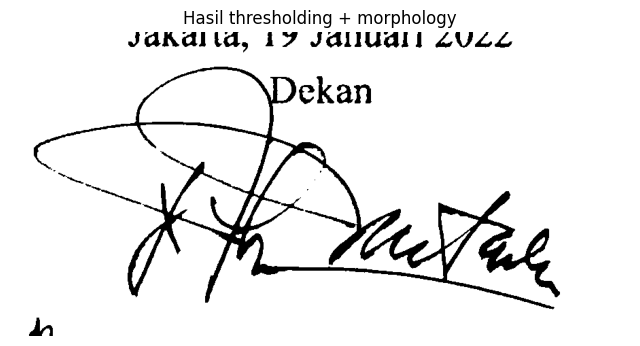

Tanda Tangan : PRESENT
Persentase piksel tinta: 7.96%
Jika hasil keliru, periksa ROI tanda tangan dan sesuaikan ink_threshold.


In [27]:
def detect_signature(roi, ink_threshold=0.01):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY) if roi.ndim == 3 else roi.copy()
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    ink_ratio = np.count_nonzero(closed) / max(1, closed.size)
    label = "PRESENT" if ink_ratio >= ink_threshold else "ABSENT"
    return label, ink_ratio, 255 - closed

signature_status, ink_ratio, signature_binary = detect_signature(signature_roi, ink_threshold=0.01)
plt.figure(figsize=(8, 4))
plt.imshow(signature_binary, cmap="gray")
plt.title("Hasil thresholding + morphology")
plt.axis("off")
plt.show()
print("Tanda Tangan :", signature_status)
print(f"Persentase piksel tinta: {ink_ratio*100:.2f}%")
print("Jika hasil keliru, periksa ROI tanda tangan dan sesuaikan ink_threshold.")


## 6. Output ringkas

In [28]:
# Pilih metode yang ingin dijadikan hasil OCR akhir setelah melihat hasil dan pengujian.
selected_method = "CLAHE"
final_number = predictions[selected_method]
print(f"Nomor Ijazah : {final_number or '[tidak terbaca]'}")
print(f"Tanda Tangan : {signature_status}")


Nomor Ijazah : NOMORYAZAH571012022000056
Tanda Tangan : PRESENT


## 7. Evaluasi CER (opsional, disarankan)

Masukkan nomor ijazah yang benar-benar terlihat pada gambar sebagai `ground_truth`. CER terendah menunjukkan OCR paling mendekati teks referensi pada gambar ini. Untuk kesimpulan yang lebih kuat, ulangi pada banyak gambar uji.

In [29]:
def character_error_rate(reference, hypothesis):
    ref = re.sub(r"\\s+", "", str(reference).upper())
    hyp = re.sub(r"\\s+", "", str(hypothesis).upper())
    if not ref:
        return 0.0 if not hyp else 1.0
    previous = list(range(len(hyp) + 1))
    for i, rc in enumerate(ref, 1):
        current = [i]
        for j, hc in enumerate(hyp, 1):
            current.append(min(
                current[-1] + 1,       # insertion
                previous[j] + 1,        # deletion
                previous[j-1] + (rc != hc)  # substitution
            ))
        previous = current
    return previous[-1] / len(ref)

ground_truth = "DN-123456789"  # GANTI dengan nomor yang benar pada gambar yang diuji
cer_scores = {method: character_error_rate(ground_truth, pred)
              for method, pred in predictions.items()}
print("CER per metode (lebih rendah lebih baik):")
for method, cer in sorted(cer_scores.items(), key=lambda item: item[1]):
    print(f"{method:20s}: {cer:.4f} ({cer*100:.2f}%)")
best_method = min(cer_scores, key=cer_scores.get)
print(f"\nMetode dengan CER terendah untuk gambar ini: {best_method}")


CER per metode (lebih rendah lebih baik):
Grayscale           : 1.9167 (191.67%)
CLAHE               : 1.9167 (191.67%)
Denoising           : 1.9167 (191.67%)
Sharpening          : 1.9167 (191.67%)
Otsu threshold      : 1.9167 (191.67%)
Adaptive threshold  : 56.1667 (5616.67%)

Metode dengan CER terendah untuk gambar ini: Grayscale


## Interpretasi dan batasan
- Metode dengan CER terendah hanya dapat disebut terbaik **untuk data yang diuji**. Gunakan banyak citra ijazah dan hitung rata-rata CER sebelum menyimpulkan.
- Koordinat ROI contoh bukan koordinat universal; sesuaikan untuk setiap format/hasil scan.
- Deteksi tanda tangan adalah heuristik berbasis jumlah piksel tinta. Stempel, teks, garis tabel, dan noise dapat memengaruhi hasil. Ini bukan pemeriksaan keaslian.
- Untuk tugas, dokumentasikan citra uji, ground truth, hasil tiap metode, rata-rata CER, serta contoh hasil deteksi tanda tangan.
